# Exploratory Data Analysis - Boom Challenge Forward Prediction

**Objective:** understand the structure of the asteroid impact dataset, identify the main physical regimes, analyze target behavior, and define the modeling strategy for the next notebook.

This notebook focuses on the **Forward Prediction** task:

> Predict six ejecta outcomes from eight impact parameters.

The EDA is organized to support the next steps:
1. Baseline modeling
2. Physics-inspired feature engineering
3. Robust validation for potential out-of-distribution test scenarios
4. Inverse design strategy

## Data Dictionary

This dataset describes simulated asteroid impact scenarios and the resulting ejecta outcomes.  
The objective is to predict the ejecta outcomes from the physical impact parameters.

### Input Features

| Variable | Type | Description | Physical Interpretation |
|---|---|---|---|
| `energy` | Numerical | Impact energy | Represents the energy released during the asteroid impact. Higher energy may increase fragmentation and ejecta travel distance. |
| `angle_rad` | Numerical | Impact angle from the horizon, measured in radians | Describes the angle at which the asteroid hits the surface. It can influence the horizontal and vertical components of ejecta motion. |
| `coupling` | Numerical | Energy transfer efficiency between the asteroid and the surface | Measures how efficiently impact energy is transferred to the target material. Higher coupling may increase fragmentation and ejecta displacement. |
| `strength` | Numerical | Material strength | Represents the resistance of the impacted material. Higher strength may produce larger fragments and reduce fine fragmentation. |
| `porosity` | Numerical | Material porosity | Measures the void fraction or porous nature of the material. Higher porosity may affect energy absorption and fragmentation behavior. |
| `gravity` | Numerical | Surface gravity | Represents the gravitational acceleration of the impacted planetary body. Higher gravity generally reduces ejecta travel distances. |
| `atmosphere` | Numerical | Atmospheric density at the impact altitude | Represents the density of the atmosphere through which fragments travel. It may affect drag and fragment displacement. |
| `shape_factor` | Numerical | Fragment irregularity factor | Describes how irregular the fragments tend to be. A higher value indicates that the material may fracture into more irregular shards. |

---

### Target Variables

| Variable | Type | Description | Physical Interpretation |
|---|---|---|---|
| `P80` | Numerical | Fragment diameter in millimeters below which 80% of the total ejected mass lies | A mass-weighted size indicator. Lower `P80` means stronger fragmentation into smaller pieces, while higher `P80` means larger fragments dominate. |
| `fines_frac` | Numerical | Fraction of total ejecta mass contributed by fragments smaller than 40 mm | Measures the proportion of fine/small fragments. Higher values indicate more fine fragmentation. |
| `oversize_frac` | Numerical | Fraction of total ejecta mass contributed by fragments larger than 120 mm | Measures the proportion of large fragments. Higher values indicate that more mass remains in large pieces. |
| `R95` | Numerical | Landing distance in meters below which 95% of the total ejected mass lies | A global ejecta range metric. Higher `R95` means the ejecta field spreads farther from the impact point. |
| `R50_fines` | Numerical | Median landing distance in meters for fragments smaller than 40 mm, mass-weighted | Measures how far the small fragments typically travel. It is the distance below which 50% of the mass of fine fragments lands. |
| `R50_oversize` | Numerical | Median landing distance in meters for fragments larger than 120 mm, mass-weighted | Measures how far the large fragments typically travel. It is the distance below which 50% of the mass of oversized fragments lands. |

---

### Target Variable Formulas

The target variables are mass-weighted statistical summaries of the simulated ejecta field.

Let:

- `d_i` = diameter of fragment `i`
- `r_i` = landing distance of fragment `i`
- `m_i` = mass of fragment `i`
- `M_total` = total ejected mass

Then:

| Variable | Formula / Definition |
|---|---|
| `P80` | Diameter `d` such that the cumulative mass of fragments with `d_i <= d` equals 80% of total ejected mass. |
| `fines_frac` | Total mass of fragments with `d_i < 40 mm` divided by total ejected mass. |
| `oversize_frac` | Total mass of fragments with `d_i > 120 mm` divided by total ejected mass. |
| `R95` | Distance `r` such that the cumulative mass of fragments with `r_i <= r` equals 95% of total ejected mass. |
| `R50_fines` | Distance `r` such that 50% of the mass of fragments smaller than 40 mm lands within distance `r`. |
| `R50_oversize` | Distance `r` such that 50% of the mass of fragments larger than 120 mm lands within distance `r`. |

---

### Modeling Interpretation

The problem is a multi-output regression task:

```text
Input impact parameters
        ↓
Machine Learning model
        ↓
Predicted ejecta outcomes

## 1. Imports and Project Paths

The project is designed to run locally in VS Code using a `.venv` environment, and it can also run on Google Colab if the paths are adjusted.

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# Detect project root whether the notebook is opened from /notebooks or the project root
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

FORWARD_DIR = PROJECT_ROOT / "data" / "raw" / "forward_prediction"
INVERSE_DIR = PROJECT_ROOT / "data" / "raw" / "inverse_design"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Forward data directory:", FORWARD_DIR)
print("Inverse design directory:", INVERSE_DIR)

Project root: /home/alouiyaz/projects/boom-challenge-ejecta-prediction
Forward data directory: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/raw/forward_prediction
Inverse design directory: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/raw/inverse_design


## 2. Load the Data

The training set contains the input impact parameters, while `train_labels.csv` contains the six target ejecta outcomes.  
The test set contains the same eight input features but no labels.

In [3]:
train = pd.read_csv(FORWARD_DIR / "train.csv")
labels = pd.read_csv(FORWARD_DIR / "train_labels.csv")
test = pd.read_csv(FORWARD_DIR / "test.csv")
submission_template = pd.read_csv(FORWARD_DIR / "prediction_submission_template.csv")

print("Train shape:", train.shape)
print("Labels shape:", labels.shape)
print("Test shape:", test.shape)
print("Submission template shape:", submission_template.shape)

display(train.head())
display(labels.head())
display(test.head())
display(submission_template.head())

Train shape: (2930, 8)
Labels shape: (2930, 6)
Test shape: (492, 8)
Submission template shape: (1, 7)


,porosity,atmosphere,gravity,coupling,strength,shape_factor,energy,angle_rad
0,0.337215,0.781263,3.71,0.861258,1.305809,0.784028,3.826405,0.818303
1,0.058029,0.136205,1.62,0.561245,3.494501,0.922737,2.828754,1.193036
2,0.315632,0.774704,3.71,0.948860,1.366386,0.954922,3.068907,0.605872
3,0.033062,0.144204,1.62,0.713705,3.599419,0.932911,2.700574,1.073708
4,0.278207,0.414620,9.81,1.237205,1.996742,1.260855,3.484022,0.863568


,P80,fines_frac,oversize_frac,R95,R50_fines,R50_oversize
0,76.972350,0.184728,0.016671,198.938699,175.527939,76.235779
1,269.057465,0.000622,0.916734,239.268477,447.157838,141.894047
2,104.070923,0.070343,0.094438,192.986417,189.286407,84.235774
3,257.618403,0.001026,0.880122,289.289693,500.000028,169.866473
4,111.717167,0.058576,0.136166,94.229304,97.614864,42.928393


,porosity,atmosphere,gravity,coupling,strength,shape_factor,energy,angle_rad
0,0.162194,0.100630,1.38,1.305063,1.864599,0.870897,4.387076,0.937830
1,0.265631,0.708493,4.91,0.720038,1.803294,1.188009,4.259426,0.848536
2,0.114929,0.292809,1.02,1.003443,1.172195,0.957242,4.384792,1.020636
3,0.228540,0.787507,1.02,0.501471,2.721400,1.365608,4.580126,0.888316
4,0.184185,0.237429,4.91,1.170230,2.079364,0.880140,3.607383,1.086271


,scenario_id,P80,fines_frac,oversize_frac,R95,R50_fines,R50_oversize
0,0,90.0,0.1,0.12,250.0,190.0,115.0


### Initial Observation

From the loaded files:

- `train.csv`: **2930 rows × 8 input features**
- `train_labels.csv`: **2930 rows × 6 target variables**
- `test.csv`: **492 rows × 8 input features**
- `prediction_submission_template.csv`: one example row showing the expected submission format

This confirms that the problem is a **multi-output regression task**, not a classification problem.

In [4]:
input_cols = [
    "energy",
    "angle_rad",
    "coupling",
    "strength",
    "porosity",
    "gravity",
    "atmosphere",
    "shape_factor"
]

target_cols = [
    "P80",
    "fines_frac",
    "oversize_frac",
    "R95",
    "R50_fines",
    "R50_oversize"
]

print("Input columns:", input_cols)
print("Target columns:", target_cols)

Input columns: ['energy', 'angle_rad', 'coupling', 'strength', 'porosity', 'gravity', 'atmosphere', 'shape_factor']
Target columns: ['P80', 'fines_frac', 'oversize_frac', 'R95', 'R50_fines', 'R50_oversize']


## 3. Basic Data Quality Checks

This section checks:
- column consistency between train and test
- data types
- missing values
- duplicated rows

In [5]:
print("Train columns:")
print(train.columns.tolist())

print("\nLabels columns:")
print(labels.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

print("\nSubmission template columns:")
print(submission_template.columns.tolist())

assert set(train.columns) == set(test.columns), "Train and test columns do not match."
assert list(labels.columns) == target_cols, "Target columns do not match expected format."

Train columns:
['porosity', 'atmosphere', 'gravity', 'coupling', 'strength', 'shape_factor', 'energy', 'angle_rad']

Labels columns:
['P80', 'fines_frac', 'oversize_frac', 'R95', 'R50_fines', 'R50_oversize']

Test columns:
['porosity', 'atmosphere', 'gravity', 'coupling', 'strength', 'shape_factor', 'energy', 'angle_rad']

Submission template columns:
['scenario_id', 'P80', 'fines_frac', 'oversize_frac', 'R95', 'R50_fines', 'R50_oversize']


In [6]:
print("Train info:")
train.info()

print("\nLabels info:")
labels.info()

print("\nTest info:")
test.info()

Train info:
<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   porosity      2930 non-null   float64
 1   atmosphere    2930 non-null   float64
 2   gravity       2930 non-null   float64
 3   coupling      2930 non-null   float64
 4   strength      2930 non-null   float64
 5   shape_factor  2930 non-null   float64
 6   energy        2930 non-null   float64
 7   angle_rad     2930 non-null   float64
dtypes: float64(8)
memory usage: 183.3 KB

Labels info:
<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   P80            2930 non-null   float64
 1   fines_frac     2930 non-null   float64
 2   oversize_frac  2930 non-null   float64
 3   R95            2930 non-null   float64
 4   R50_fines      2930 non-null   float64
 5  

In [7]:
df = pd.concat([train, labels], axis=1)

missing_df = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_count", ascending=False)

missing_test = pd.DataFrame({
    "missing_count": test.isna().sum(),
    "missing_percent": test.isna().mean() * 100
}).sort_values("missing_count", ascending=False)

print("Missing values in training data:")
display(missing_df)

print("Missing values in test data:")
display(missing_test)

print("Duplicated rows in train:", train.duplicated().sum())
print("Duplicated rows in test:", test.duplicated().sum())

Missing values in training data:


,missing_count,missing_percent
porosity,0,0.0
atmosphere,0,0.0
gravity,0,0.0
coupling,0,0.0
strength,0,0.0
shape_factor,0,0.0
energy,0,0.0
angle_rad,0,0.0
P80,0,0.0
fines_frac,0,0.0


Missing values in test data:


,missing_count,missing_percent
porosity,0,0.0
atmosphere,0,0.0
gravity,0,0.0
coupling,0,0.0
strength,0,0.0
shape_factor,0,0.0
energy,0,0.0
angle_rad,0,0.0


Duplicated rows in train: 0
Duplicated rows in test: 0


### Data Quality Summary

The dataset is clean from a basic data quality perspective:

- All input and target variables are numerical.
- No missing values were detected in the training or test files.
- The train and test files contain the same input columns.
- The labels file has the six expected target columns.

No imputation or categorical encoding is required at this stage.

## 4. Descriptive Statistics

This section summarizes the numerical range of each input and output variable.

In [8]:
print("Input feature statistics:")
display(df[input_cols].describe().T)

print("Target variable statistics:")
display(df[target_cols].describe().T)

Input feature statistics:


,count,mean,std,min,25%,50%,75%,max
energy,2930.0,3.301926,0.515693,2.601520,2.916863,3.178629,3.550105,4.596577
angle_rad,2930.0,0.951386,0.255006,0.524044,0.709770,1.061094,1.184804,1.308300
coupling,2930.0,0.779547,0.291783,0.400526,0.580455,0.671931,0.906774,1.599823
strength,2930.0,2.580928,0.883295,0.810376,1.777277,2.948905,3.358840,3.799996
porosity,2930.0,0.164995,0.134106,0.000013,0.038808,0.076117,0.301247,0.349741
gravity,2930.0,4.960819,3.442831,1.620000,1.620000,3.710000,9.810000,9.810000
atmosphere,2930.0,0.363153,0.268377,0.050157,0.121867,0.191589,0.617854,0.849873
shape_factor,2930.0,0.985043,0.139024,0.750093,0.890412,0.948485,1.033366,1.349924


Target variable statistics:


,count,mean,std,min,25%,50%,75%,max
P80,2930.0,171.891639,65.755283,57.265208,105.231804,193.751286,229.132545,326.836650
fines_frac,2930.0,0.043865,0.068604,0.000143,0.001162,0.002956,0.065213,0.463369
oversize_frac,2930.0,0.513737,0.362087,0.002468,0.102342,0.720982,0.847226,0.968150
R95,2930.0,253.260470,238.543070,18.076380,81.540215,163.335046,349.741891,1310.623251
R50_fines,2930.0,310.884622,246.898723,30.601365,86.771923,227.164319,512.720166,1138.786538
R50_oversize,2930.0,126.181143,108.436996,11.068695,36.721097,87.601506,190.104320,716.141659


### Main Descriptive Findings

The input features have different ranges and several variables appear to follow separated physical regimes:

- `gravity` has only a few discrete values, suggesting different planetary environments.
- `angle_rad`, `strength`, `porosity`, and `atmosphere` show separated ranges.
- `energy` and `coupling` contain moderate and high-impact regimes.

The target variables have very different scales:

- `P80` ranges roughly from 57 to 327.
- `fines_frac` is bounded between 0 and about 0.46 and is strongly concentrated near zero.
- `oversize_frac` ranges from almost 0 to almost 1.
- Distance-related targets (`R95`, `R50_fines`, `R50_oversize`) are strongly right-skewed and contain large values.

This supports the idea of training **target-specific models** instead of relying only on a single multi-output model.

## 5. Input Feature Distributions

The goal is to identify physical regimes, multimodal distributions, and variables that may require engineered features.

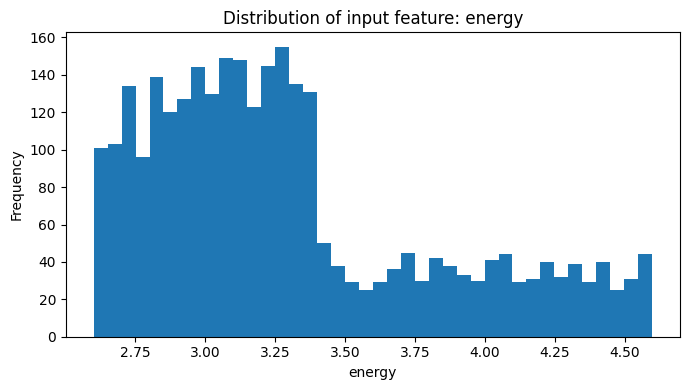

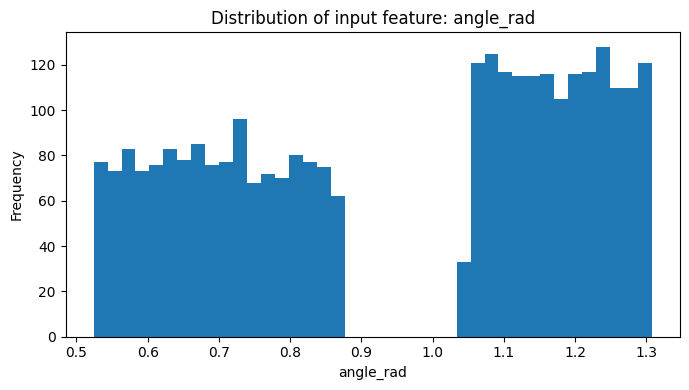

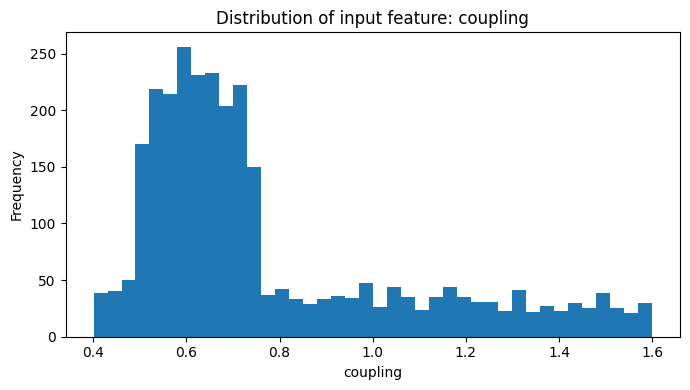

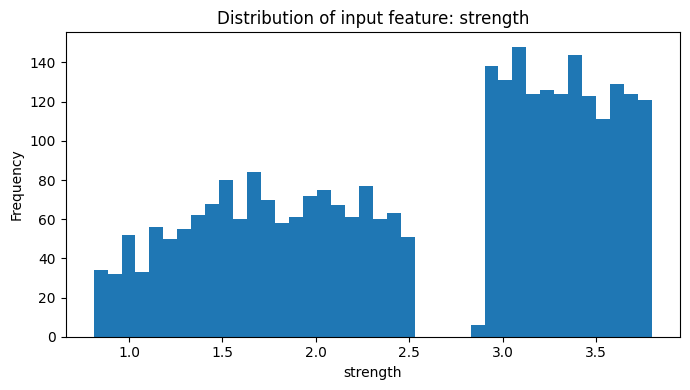

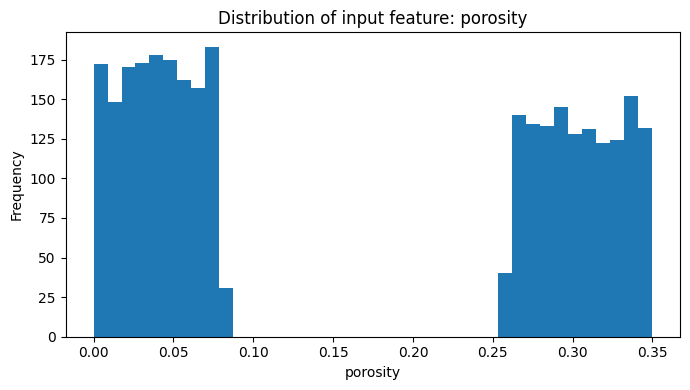

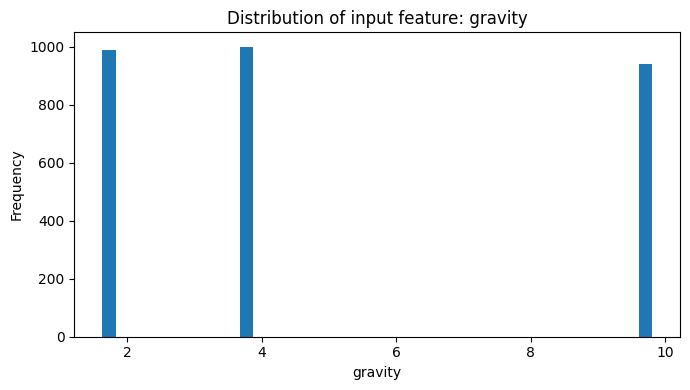

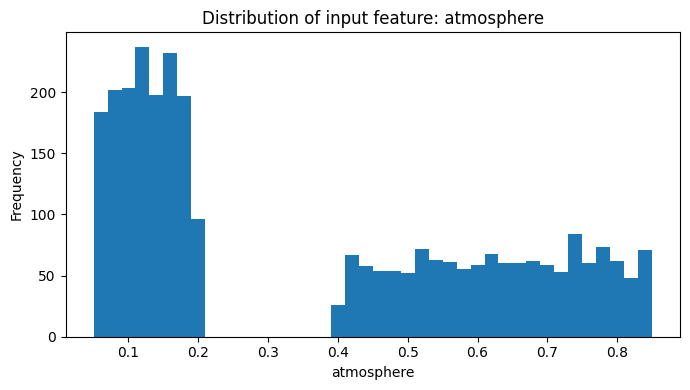

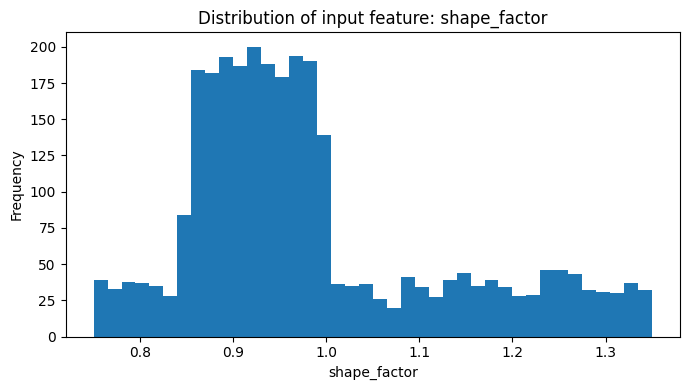

In [9]:
for col in input_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(train[col], bins=40)
    plt.title(f"Distribution of input feature: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### Input Distribution Interpretation

The input distributions suggest that the data is not generated from one simple continuous process. Several variables show clear regimes:

- `energy`: denser between low/moderate values, with another higher-energy region.
- `angle_rad`: two separated angle regimes, approximately lower-angle and higher-angle impacts.
- `coupling`: most values are moderate, but a long higher-coupling region exists.
- `strength`: two material-strength regimes.
- `porosity`: two clear regimes, low porosity and high porosity.
- `gravity`: only three main values, likely representing different planetary environments.
- `atmosphere`: low and high atmospheric-density regimes.
- `shape_factor`: mostly centered near 0.9–1.0, with a higher irregularity region.

These findings suggest that nonlinear models and interaction features will be important.

## 6. Target Variable Distributions

This section analyzes how each output variable behaves.

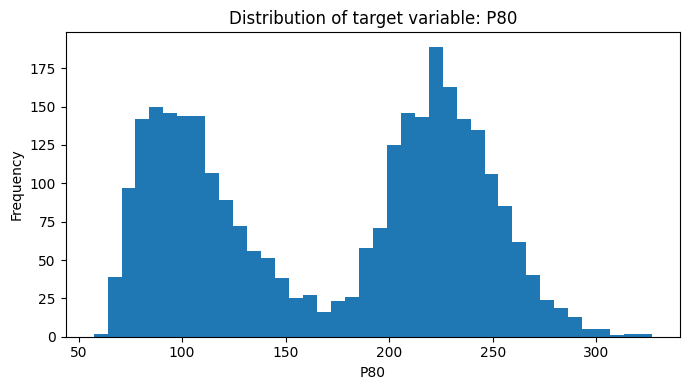

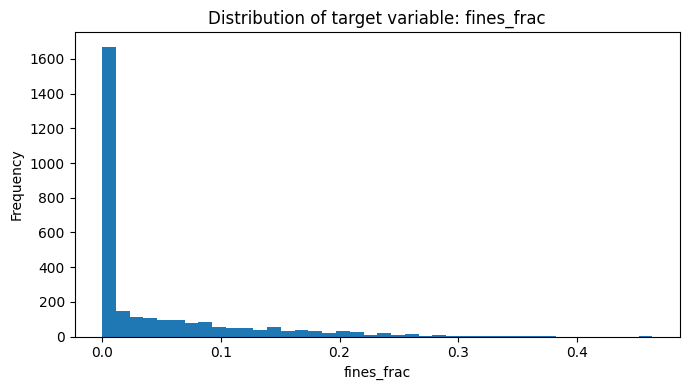

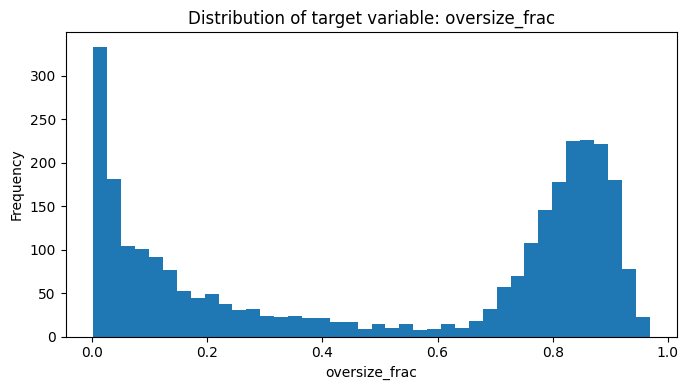

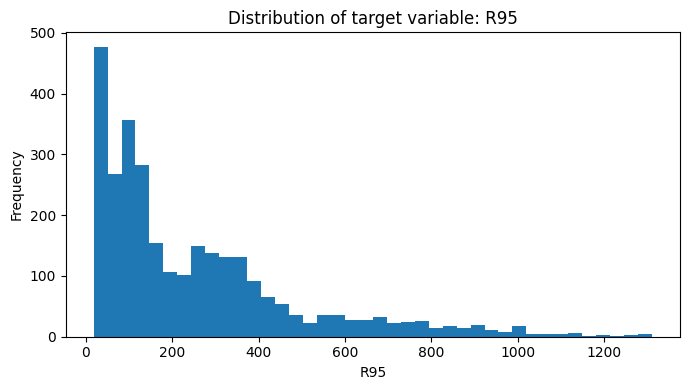

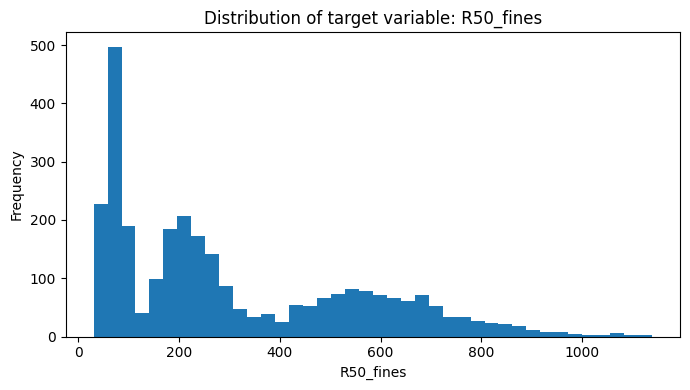

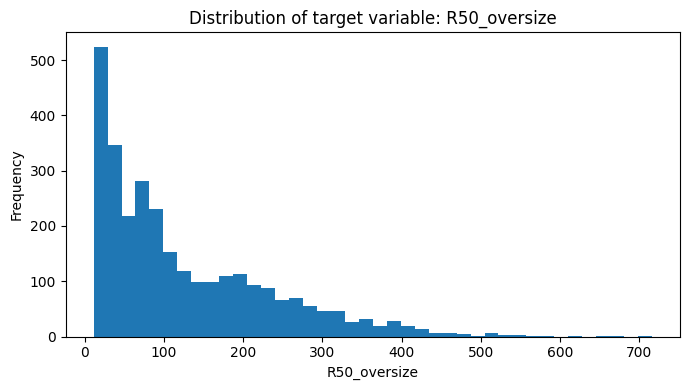

In [10]:
for col in target_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(labels[col], bins=40)
    plt.title(f"Distribution of target variable: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### Target Distribution Interpretation

The target variables show different statistical behaviors:

- `P80` is bimodal, suggesting two main fragmentation regimes.
- `fines_frac` is highly right-skewed, with most values close to zero.
- `oversize_frac` has two dominant regimes: near zero and high oversize fraction.
- `R95`, `R50_fines`, and `R50_oversize` are strongly right-skewed, with large-distance scenarios.

Modeling implications:

- Linear models alone will likely be insufficient.
- Tree-based nonlinear models are strong baseline candidates.
- Log-transformations may help for distance targets and `fines_frac`.
- Target-specific models may work better than a single global multi-output model.

## 7. Boxplots and Outlier Structure

Because this dataset comes from physical simulations, extreme values should not be automatically removed.  
They may represent valid high-energy, low-gravity, or high-dispersion scenarios.

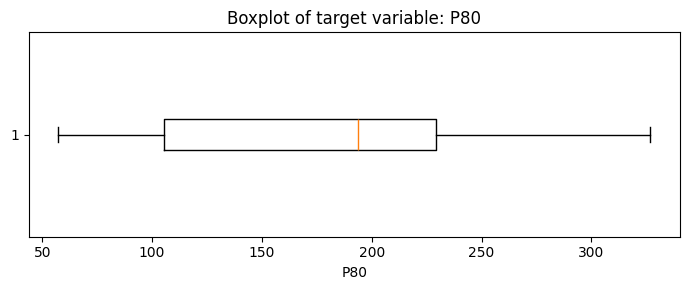

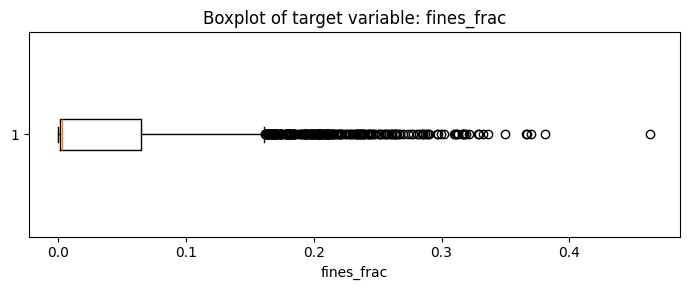

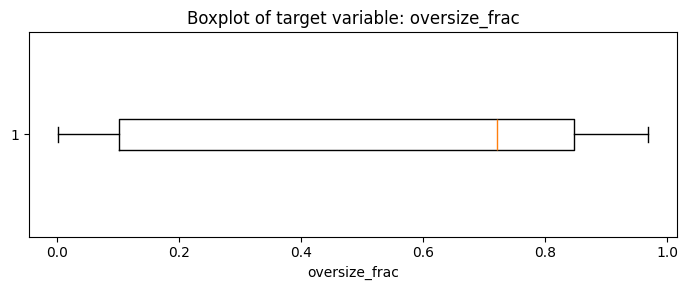

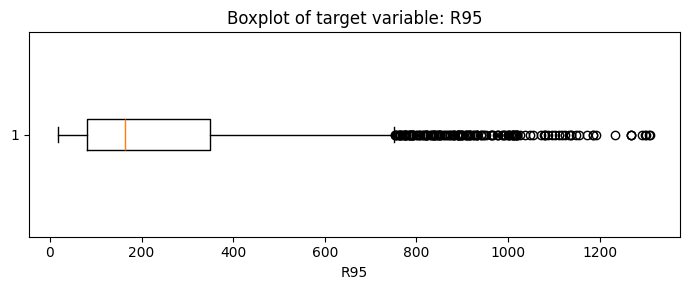

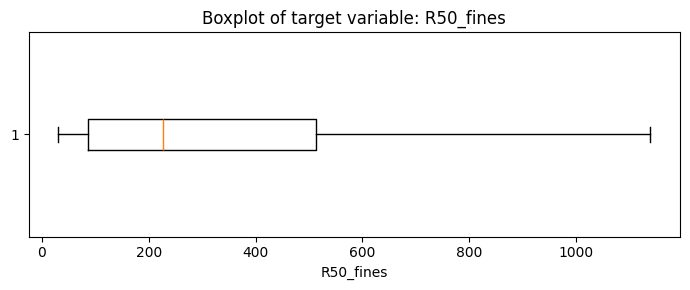

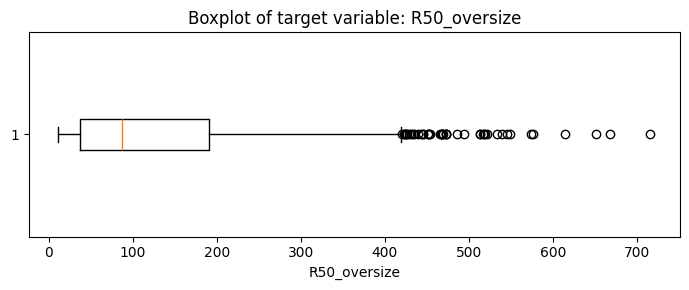

In [11]:
for col in target_cols:
    plt.figure(figsize=(7, 3))
    plt.boxplot(labels[col], vert=False)
    plt.title(f"Boxplot of target variable: {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

### Outlier Interpretation

The largest values are mainly observed in distance-related targets (`R95`, `R50_fines`, and `R50_oversize`).  
These should not be treated as data errors without evidence. Instead, the modeling strategy should include:

- robust validation,
- possible log-transformation for distance targets,
- separate error analysis for extreme values,
- careful treatment of low-gravity scenarios.

## 8. Correlation Analysis

Correlation provides a first view of linear relationships, but it does not capture nonlinear effects or interactions.

,P80,fines_frac,oversize_frac,R95,R50_fines,R50_oversize
energy,-0.637689,0.504758,-0.631570,0.280488,0.110369,0.199059
angle_rad,0.865685,-0.616796,0.883424,-0.358462,-0.120715,-0.249014
coupling,-0.679456,0.717023,-0.689839,0.330752,0.124114,0.217234
strength,0.916946,-0.732616,0.921171,-0.385416,-0.129610,-0.260524
porosity,-0.906075,0.644762,-0.923171,0.369330,0.122433,0.257679
gravity,-0.014238,0.018396,-0.013582,-0.676681,-0.803886,-0.744055
atmosphere,-0.861056,0.613226,-0.879562,0.349797,0.113785,0.249398
shape_factor,-0.408486,0.291081,-0.417427,0.129965,0.022730,0.094854


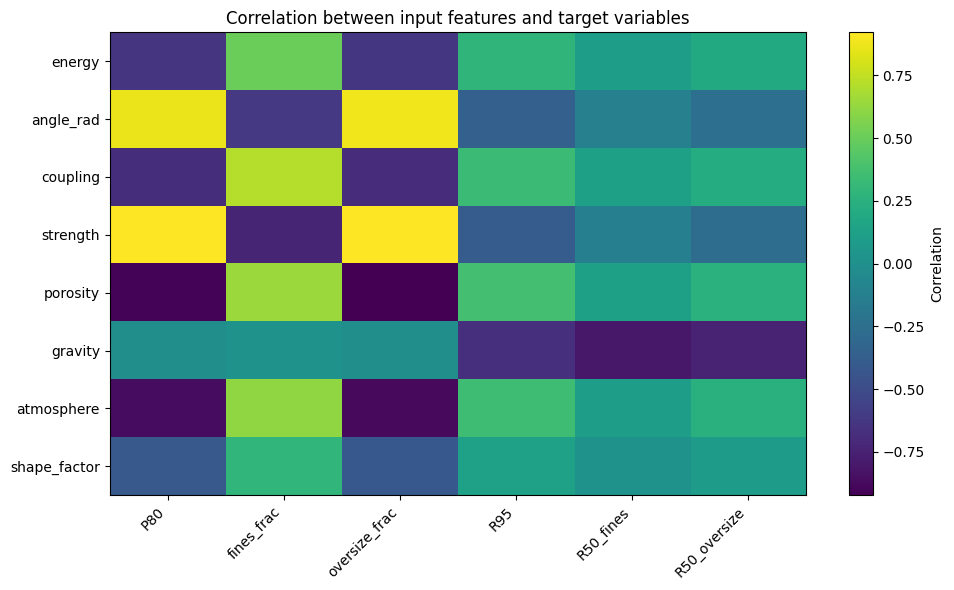

In [12]:
corr_matrix = df[input_cols + target_cols].corr()
input_target_corr = corr_matrix.loc[input_cols, target_cols]

display(input_target_corr)

plt.figure(figsize=(10, 6))
plt.imshow(input_target_corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(target_cols)), target_cols, rotation=45, ha="right")
plt.yticks(range(len(input_cols)), input_cols)
plt.title("Correlation between input features and target variables")
plt.tight_layout()
plt.show()

### Input-Target Correlation Interpretation

Important findings:

- `P80` is strongly positively correlated with `strength` and `angle_rad`.
- `P80` is strongly negatively correlated with `porosity`, `atmosphere`, `coupling`, and `energy`.
- `fines_frac` and `oversize_frac` show opposite behavior:
  - variables that increase fine fragments tend to reduce oversized fragments.
- `gravity` is the dominant variable for distance-related targets:
  - higher gravity strongly reduces `R95`, `R50_fines`, and `R50_oversize`.

This supports the use of physics-inspired feature engineering:
- effective energy
- angle decomposition
- energy-to-strength ratios
- energy-to-gravity ratios
- drag-related proxy variables

## 9. Target-to-Target Correlation

This helps identify whether the six output variables share common physical structure.

,P80,fines_frac,oversize_frac,R95,R50_fines,R50_oversize
P80,1.000000,-0.785257,0.985509,-0.417661,-0.144845,-0.285317
fines_frac,-0.785257,1.000000,-0.788210,0.413978,0.160096,0.259182
oversize_frac,0.985509,-0.788210,1.000000,-0.421883,-0.147050,-0.287540
R95,-0.417661,0.413978,-0.421883,1.000000,0.924637,0.962246
R50_fines,-0.144845,0.160096,-0.147050,0.924637,1.000000,0.965326
R50_oversize,-0.285317,0.259182,-0.287540,0.962246,0.965326,1.000000


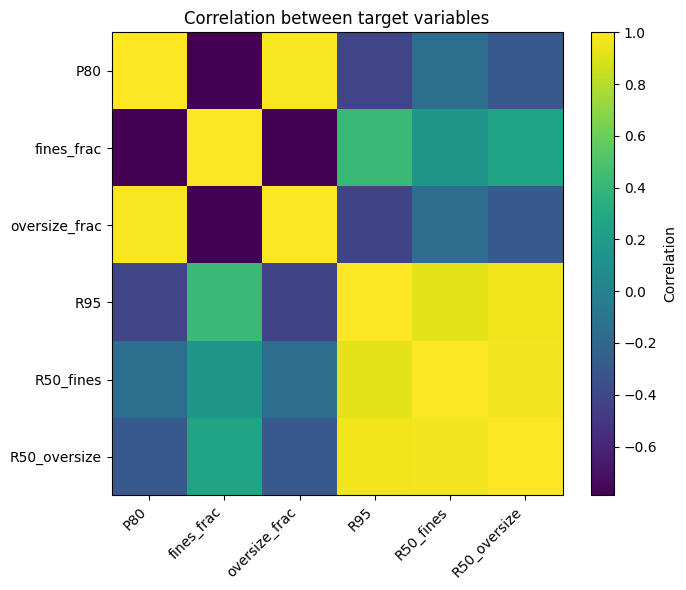

In [13]:
target_corr = labels[target_cols].corr()

display(target_corr)

plt.figure(figsize=(7, 6))
plt.imshow(target_corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(target_cols)), target_cols, rotation=45, ha="right")
plt.yticks(range(len(target_cols)), target_cols)
plt.title("Correlation between target variables")
plt.tight_layout()
plt.show()

### Target-to-Target Interpretation

Expected patterns to verify:

- `P80` should be positively related to `oversize_frac`.
- `P80` should be negatively related to `fines_frac`.
- Distance targets should be mutually related, especially `R95`, `R50_fines`, and `R50_oversize`.

This can later help with:
- consistency checks in predictions,
- multi-output modeling experiments,
- post-processing predictions if necessary.

## 10. Bivariate Analysis

The objective is to visually inspect nonlinear relationships and regime separation.

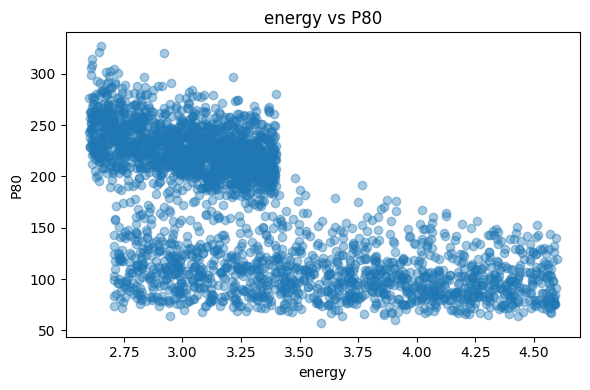

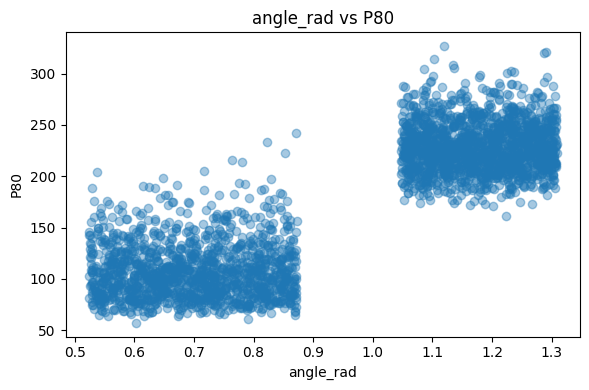

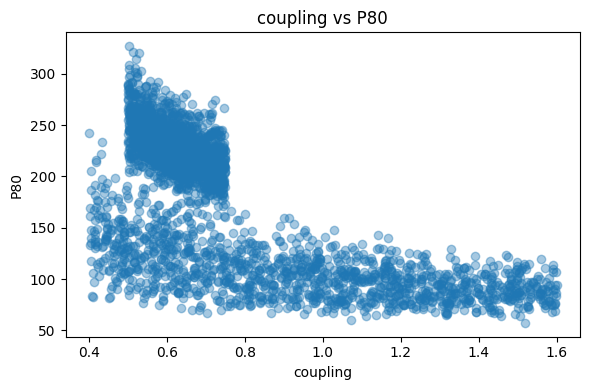

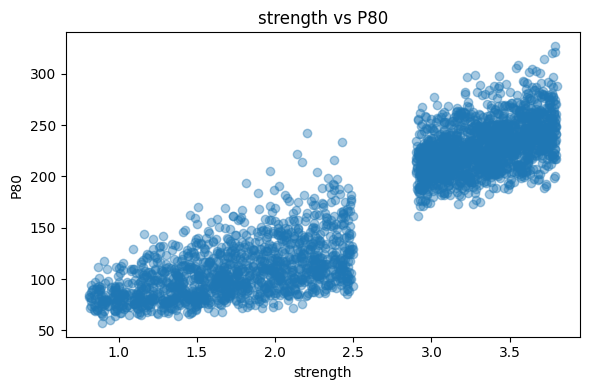

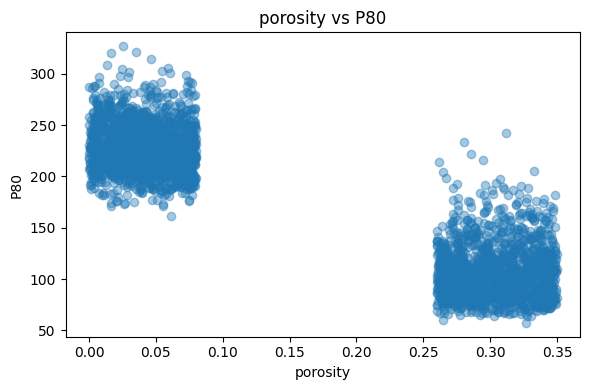

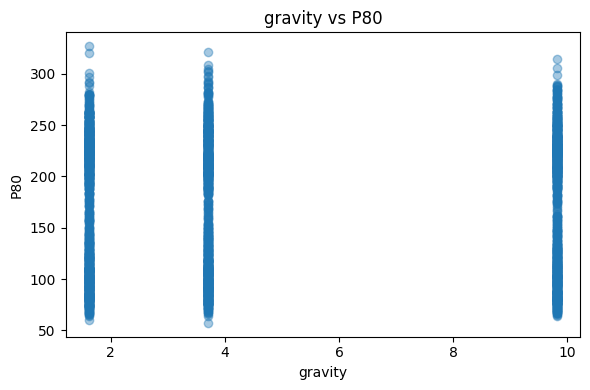

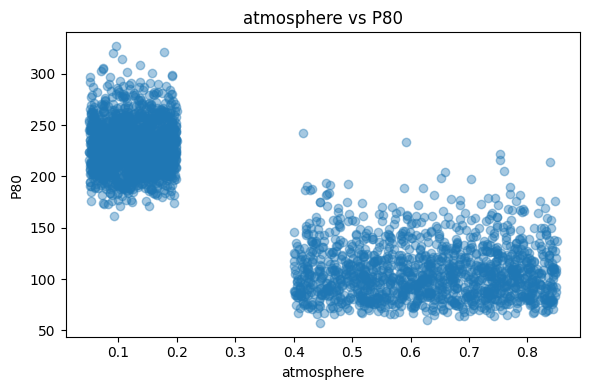

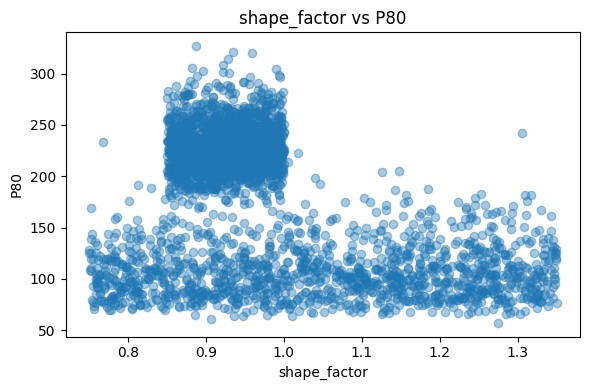

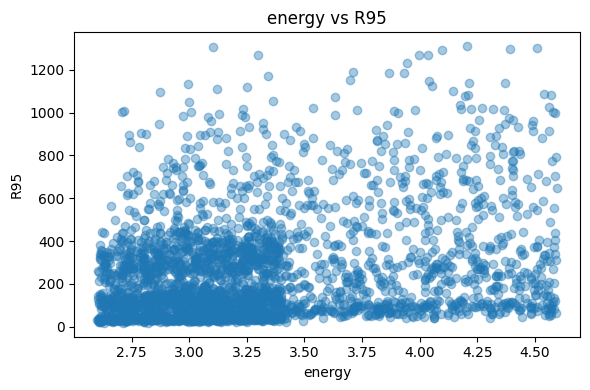

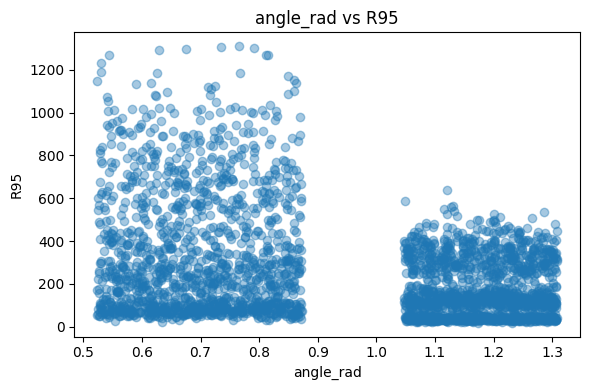

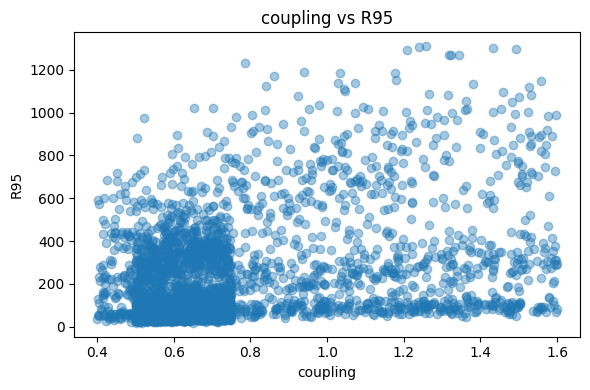

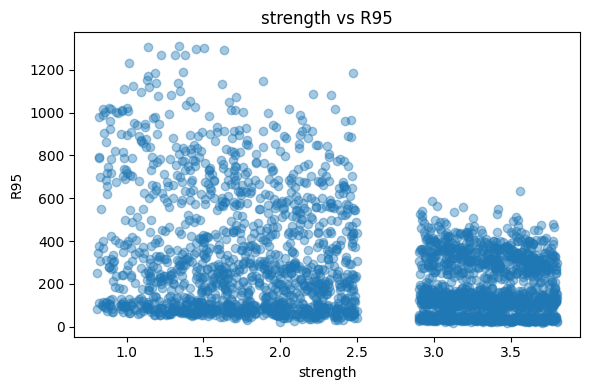

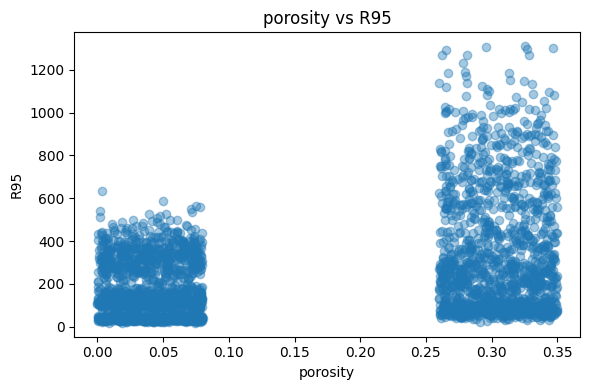

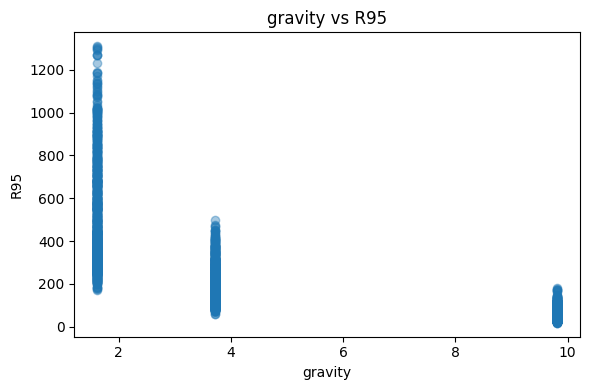

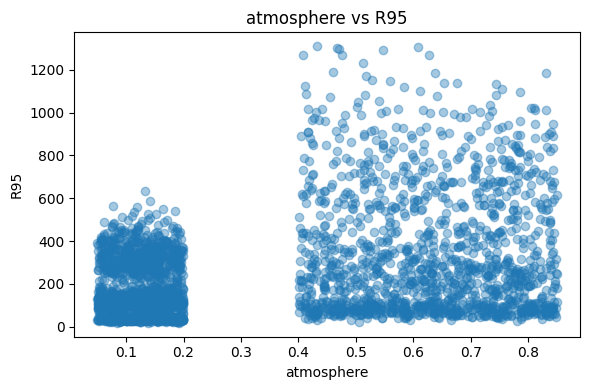

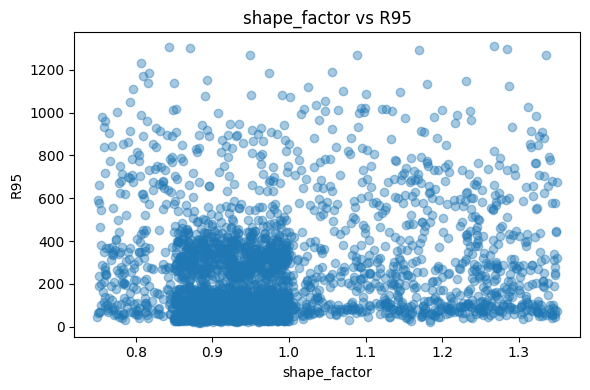

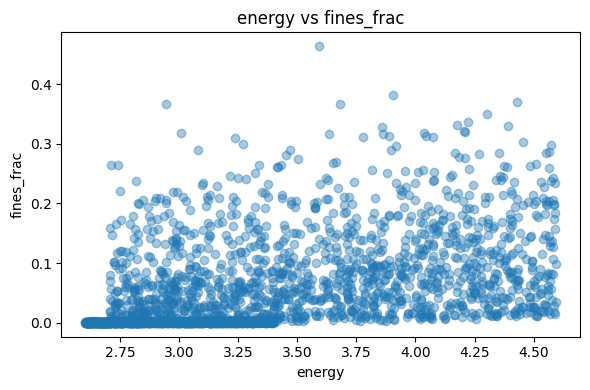

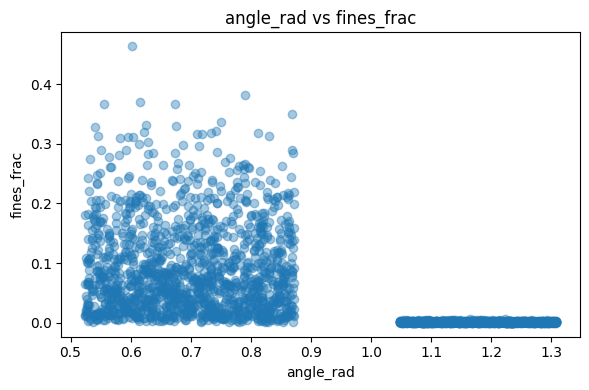

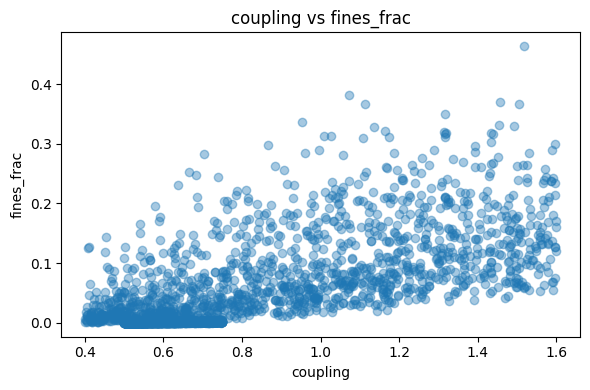

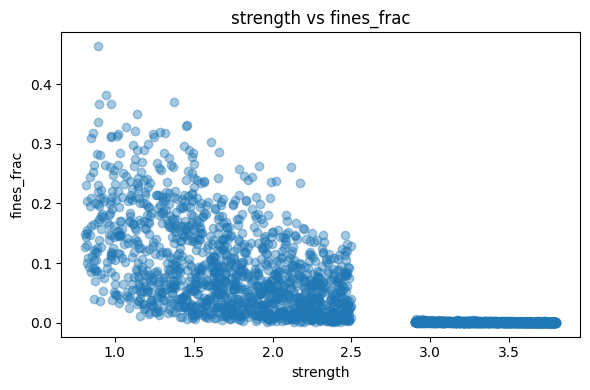

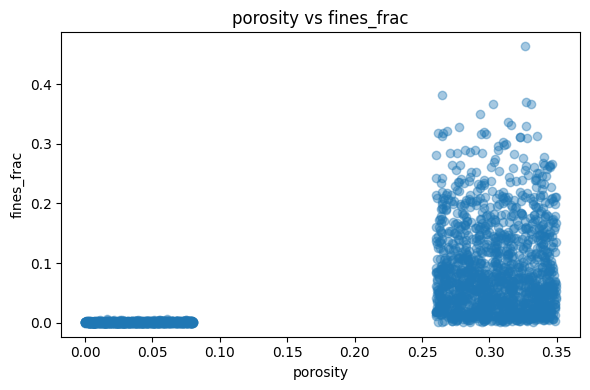

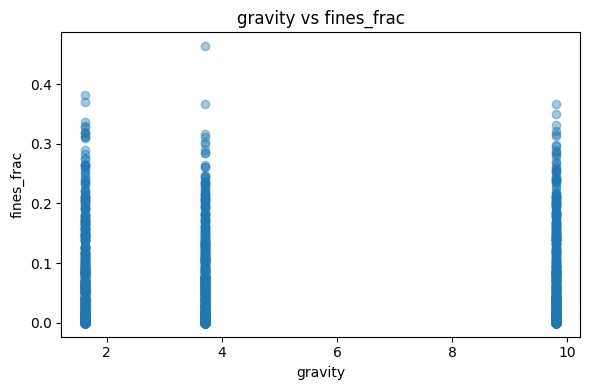

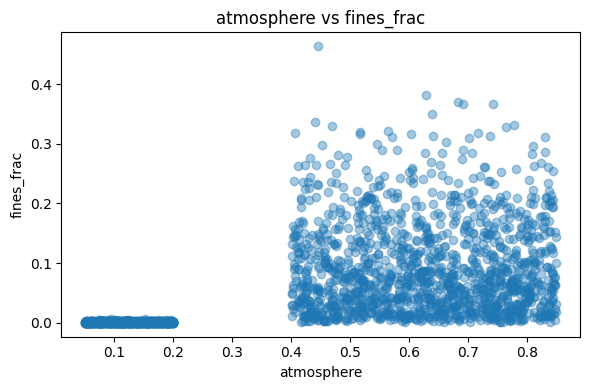

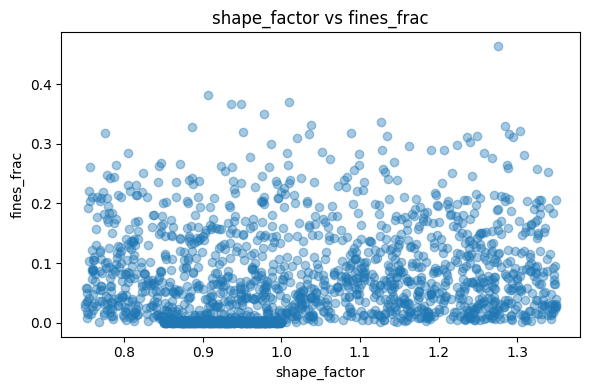

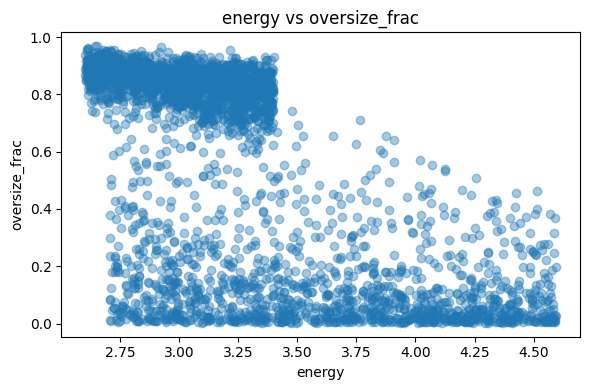

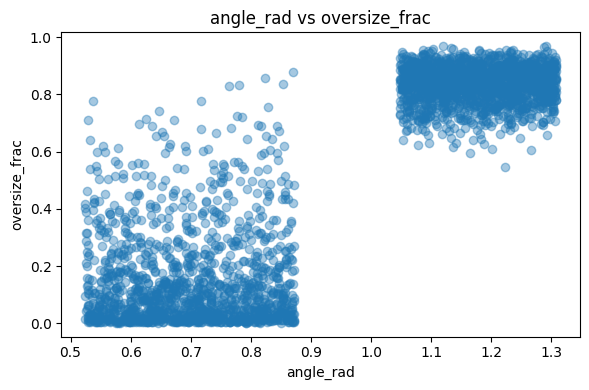

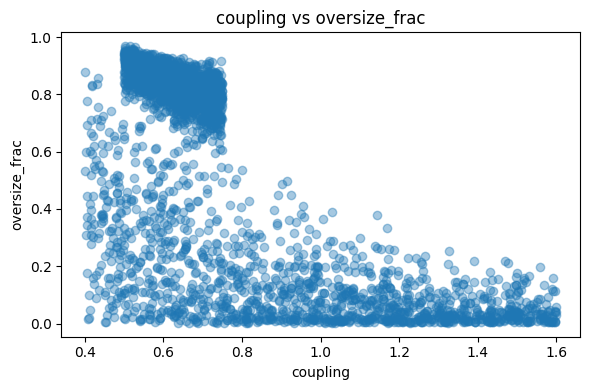

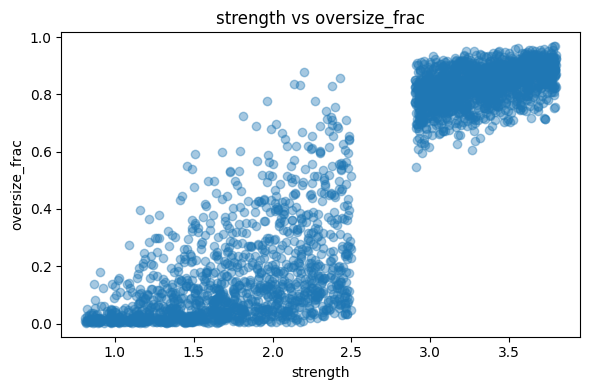

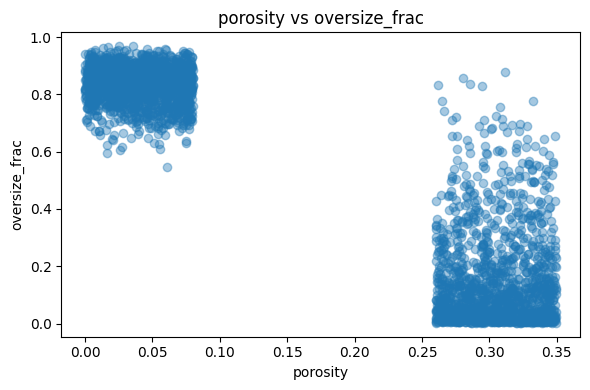

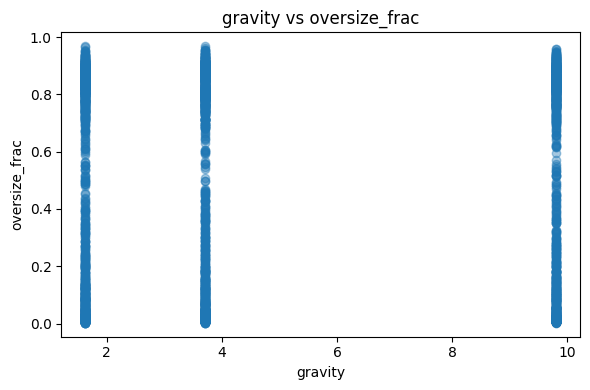

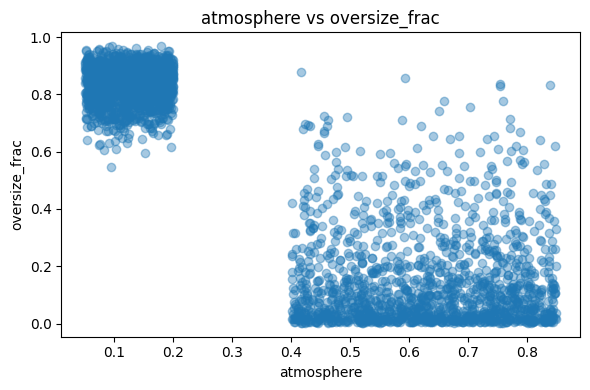

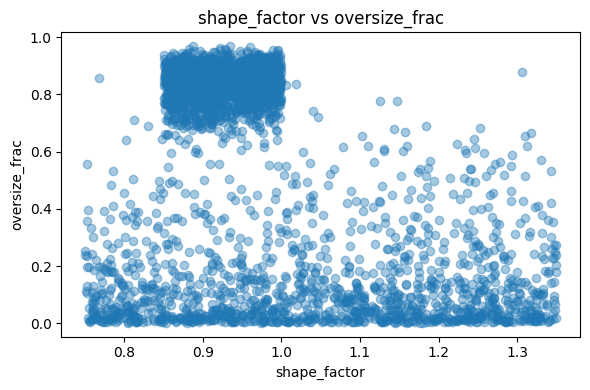

In [14]:
main_targets = ["P80", "R95", "fines_frac", "oversize_frac"]

for target in main_targets:
    for col in input_cols:
        plt.figure(figsize=(6, 4))
        plt.scatter(df[col], df[target], alpha=0.4)
        plt.title(f"{col} vs {target}")
        plt.xlabel(col)
        plt.ylabel(target)
        plt.tight_layout()
        plt.show()

### Bivariate Analysis Interpretation

From the scatter plots:

- `P80` shows strong regime separation with `angle_rad`, `strength`, `porosity`, and `atmosphere`.
- Lower porosity and higher strength are associated with larger fragments.
- High porosity and dense atmosphere are associated with smaller fragments.
- `R95` is strongly structured by gravity, with low-gravity scenarios producing much longer ranges.
- `fines_frac` is almost zero for some regimes and increases in high-fragmentation regimes.
- `oversize_frac` behaves opposite to `fines_frac`.

These patterns confirm that:
1. The dataset contains multiple physical regimes.
2. Interactions are important.
3. A simple linear model should only be used as a baseline.

## 11. Gravity Group Analysis

`gravity` behaves like a discrete environment variable rather than a fully continuous feature.  
This section analyzes target behavior by gravity level.

In [15]:
print("Gravity value counts:")
display(train["gravity"].value_counts().sort_index())

gravity_summary = df.groupby("gravity")[target_cols].agg(["mean", "median", "std", "min", "max"])
display(gravity_summary)

Gravity value counts:


gravity
1.62     990
3.71    1000
9.81     940
Name: count, dtype: int64

P80                                               fines_frac                                         oversize_frac  \
               mean      median        std        min         max       mean    median       std       min       max          mean   
gravity                                                                                                                              
1.62     172.057458  193.905567  65.748919  60.507365  326.836650   0.044202  0.002853  0.069701  0.000147  0.380800      0.515164   
3.71     173.218872  194.398035  65.439865  57.265208  321.328253   0.041332  0.002900  0.065311  0.000143  0.463369      0.519970   
9.81     170.305048  190.836025  66.132054  64.184779  313.862137   0.046206  0.003219  0.070806  0.000215  0.366057      0.505603   

                                                        R95                                                    R50_fines              \
           median       std       min       max        mean      median         std         min          max        mean      median   
gravity                                                                                                                                
1.62     0.724451  0.363199  0.002860  0.967093  504.102546  422.817670  238.782714  172.977975  1310.623251  617.765891  598.278507   
3.71     0.731661  0.359414  0.002468  0.968150  186.685165  156.469663   87.038961   59.574341   497.083255  231.088286  223.740981   
9.81     0.708865  0.363978  0.003452  0.959088   59.900523   49.985840   29.918303   18.076380   181.394580   72.569602   69.559218   

                                             R50_oversize                                                
                std         min          max         mean      median        std        min         max  
gravity                                                                                                  
1.62     149.646319  285.407826  1138.786538   251.674665  232.444336  89.146403  74.448659  716.141659  
3.71      55.305168  109.030428   437.672203    92.754582   86.329274  31.288959  34.740116  243.783652  
9.81      19.507995   30.601365   167.133854    29.572605   26.843519  11.375755  11.068695   83.829019

<Figure size 700x400 with 0 Axes>

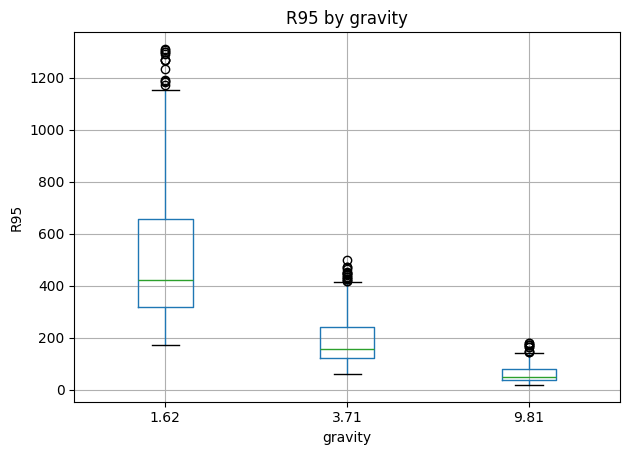

<Figure size 700x400 with 0 Axes>

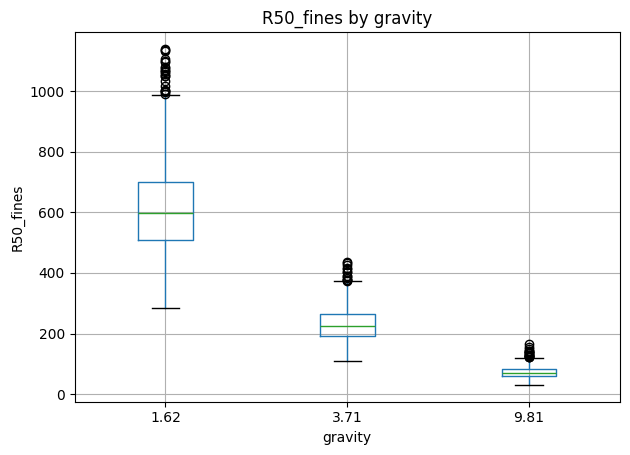

<Figure size 700x400 with 0 Axes>

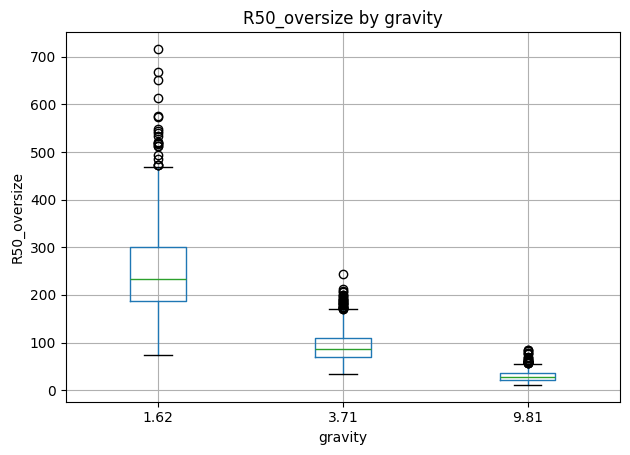

In [16]:
for target in ["R95", "R50_fines", "R50_oversize"]:
    plt.figure(figsize=(7, 4))
    df.boxplot(column=target, by="gravity")
    plt.title(f"{target} by gravity")
    plt.suptitle("")
    plt.xlabel("gravity")
    plt.ylabel(target)
    plt.tight_layout()
    plt.show()

### Gravity Analysis Interpretation

Gravity has a major effect on landing distances:

- Low gravity produces the largest `R95`, `R50_fines`, and `R50_oversize`.
- Medium gravity reduces the landing distances.
- High gravity produces the shortest landing distances.

This is physically consistent: fragments travel farther when gravity is weaker.

Modeling implications:

- `gravity` should be preserved as a key feature.
- Interactions such as `energy / gravity` and `effective_energy / gravity` should be tested.
- Validation should check model performance across gravity regimes.

## 12. Multivariate Visual Analysis

This section looks at combined effects between two inputs and one target.

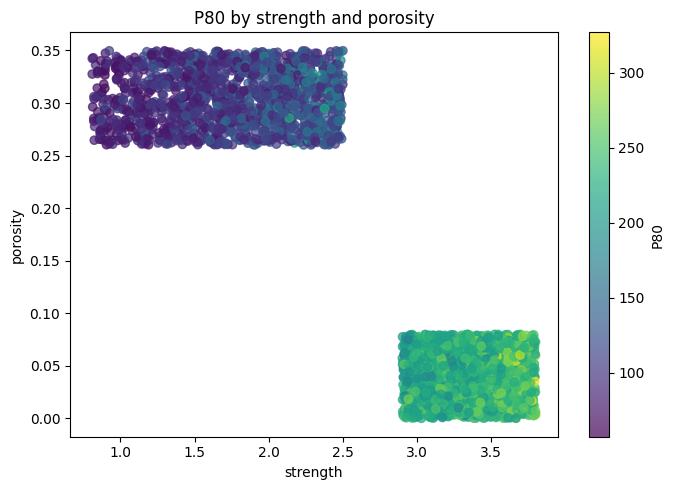

In [17]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    df["strength"],
    df["porosity"],
    c=df["P80"],
    alpha=0.7
)
plt.colorbar(scatter, label="P80")
plt.title("P80 by strength and porosity")
plt.xlabel("strength")
plt.ylabel("porosity")
plt.tight_layout()
plt.show()

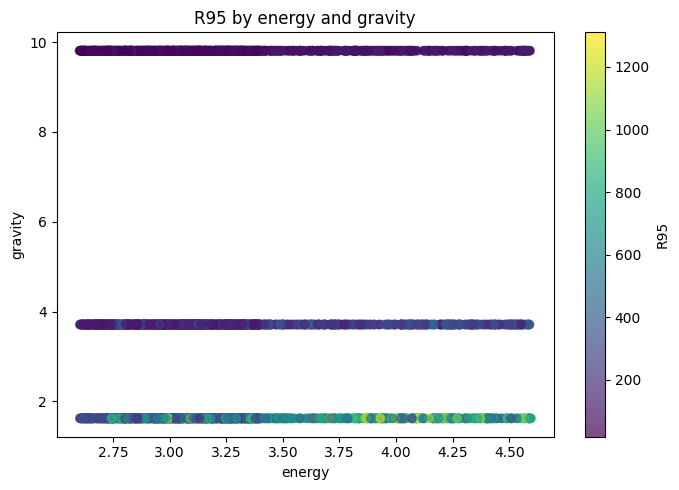

In [18]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    df["energy"],
    df["gravity"],
    c=df["R95"],
    alpha=0.7
)
plt.colorbar(scatter, label="R95")
plt.title("R95 by energy and gravity")
plt.xlabel("energy")
plt.ylabel("gravity")
plt.tight_layout()
plt.show()

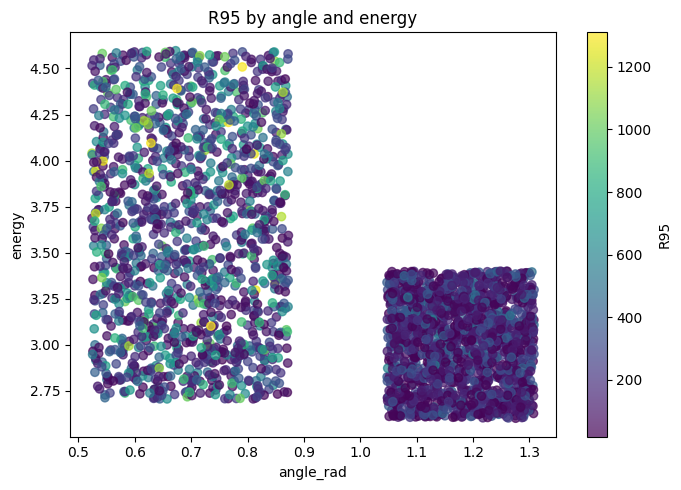

In [19]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    df["angle_rad"],
    df["energy"],
    c=df["R95"],
    alpha=0.7
)
plt.colorbar(scatter, label="R95")
plt.title("R95 by angle and energy")
plt.xlabel("angle_rad")
plt.ylabel("energy")
plt.tight_layout()
plt.show()

### Multivariate Interpretation

The multivariate plots highlight the physical regimes:

- `P80` is strongly separated by the combination of `strength` and `porosity`.
- High-strength and low-porosity regions tend to produce larger fragments.
- Low-gravity scenarios dominate long-distance ejecta outcomes.
- The relationship between `angle_rad`, `energy`, and `R95` is regime-dependent.

This supports adding interaction features and evaluating models by physical regimes.

## 13. Train-Test Distribution Shift

This is a critical step because the challenge test set may contain out-of-distribution scenarios.  
We compare the train and test input distributions before modeling.

In [20]:
train_test_ranges = pd.DataFrame({
    "train_min": train[input_cols].min(),
    "train_max": train[input_cols].max(),
    "test_min": test[input_cols].min(),
    "test_max": test[input_cols].max(),
})

train_test_ranges["test_below_train_min"] = train_test_ranges["test_min"] < train_test_ranges["train_min"]
train_test_ranges["test_above_train_max"] = train_test_ranges["test_max"] > train_test_ranges["train_max"]

display(train_test_ranges)

,train_min,train_max,test_min,test_max,test_below_train_min,test_above_train_max
energy,2.601520,4.596577,3.014554,4.696348,False,True
angle_rad,0.524044,1.308300,0.700266,1.213174,False,False
coupling,0.400526,1.599823,0.200334,1.691957,True,True
strength,0.810376,3.799996,0.900823,4.193536,False,True
porosity,0.000013,0.349741,0.080113,0.328892,False,False
gravity,1.620000,9.810000,1.020000,10.470000,True,True
atmosphere,0.050157,0.849873,0.002391,0.999355,True,True
shape_factor,0.750093,1.349924,0.703532,1.495898,True,True


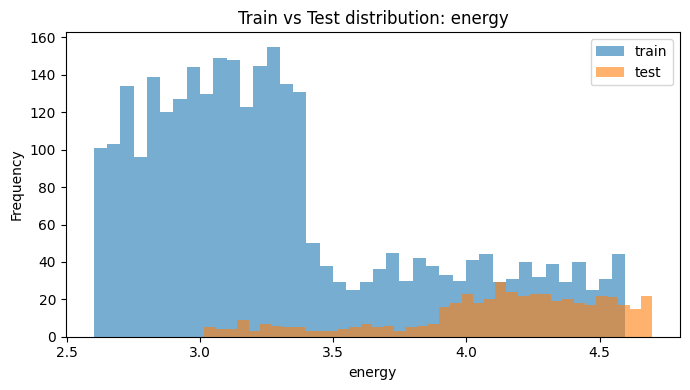

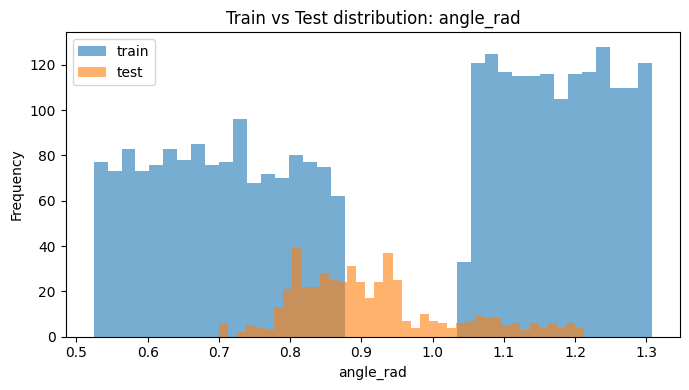

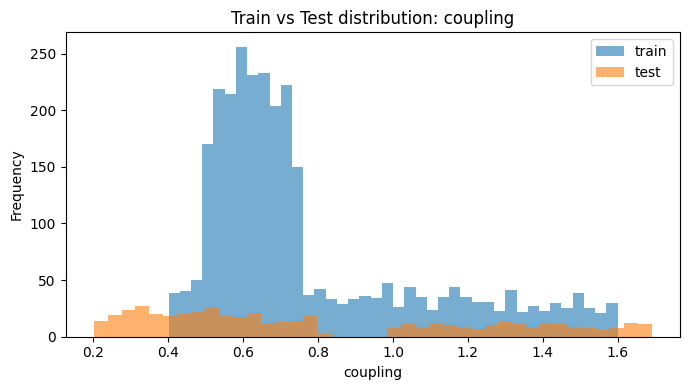

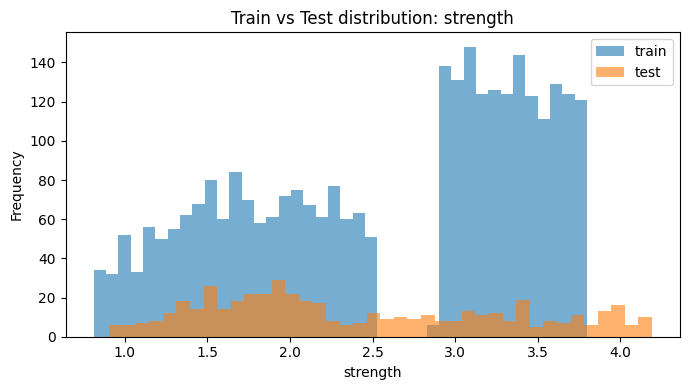

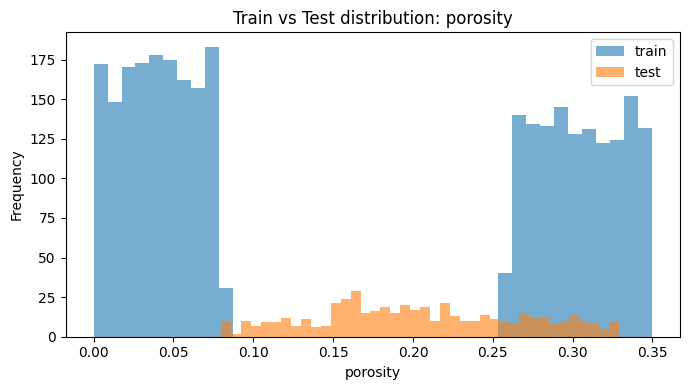

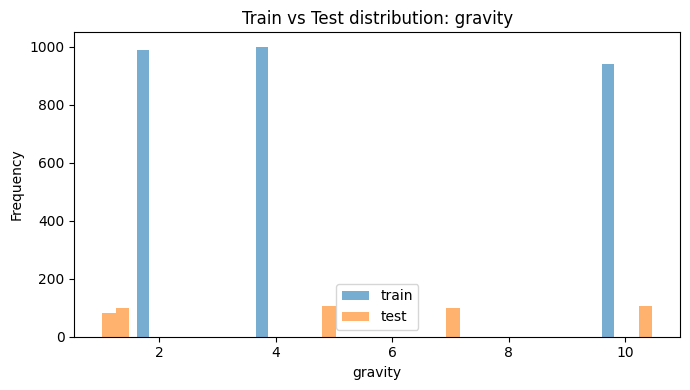

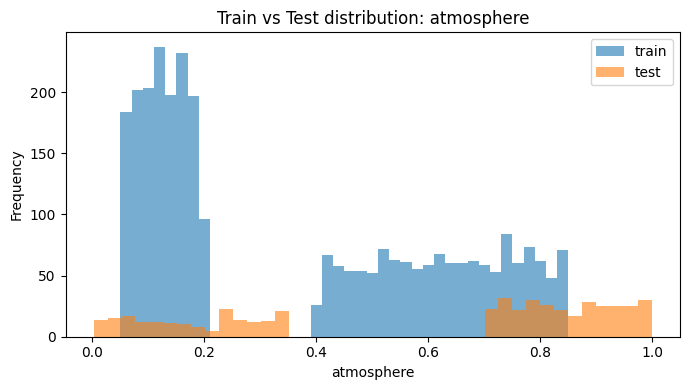

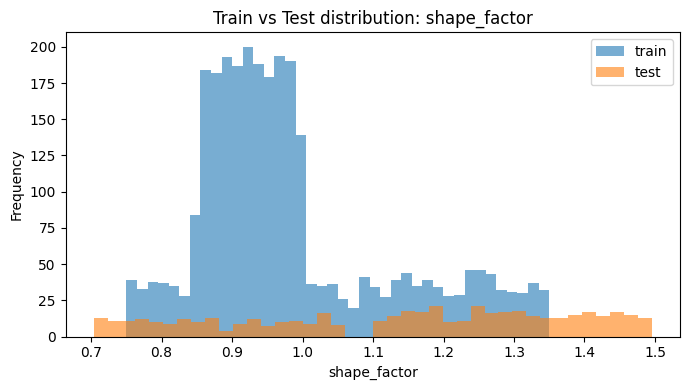

In [21]:
for col in input_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(train[col], bins=40, alpha=0.6, label="train")
    plt.hist(test[col], bins=40, alpha=0.6, label="test")
    plt.title(f"Train vs Test distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Train-Test Shift Interpretation

This section must be interpreted after running the notebook.

Key questions:

- Are test values outside the training range?
- Does the test set use different gravity values?
- Are energy, atmosphere, or angle distributions shifted?
- Are test scenarios concentrated in more extreme regions?

If strong train-test shift is found, the next modeling notebook should include:
- validation by regimes,
- robust feature engineering,
- models that generalize better outside simple random splits,
- careful error analysis on extreme scenarios.

## 14. Feature Engineering Candidates

Based on the EDA, the following features should be tested in the modeling stage.

In [22]:
def add_physics_features(X: pd.DataFrame) -> pd.DataFrame:
    """Create physics-inspired features for the Boom Challenge dataset."""
    X = X.copy()
    eps = 1e-9

    # Angle decomposition
    X["sin_angle"] = np.sin(X["angle_rad"])
    X["cos_angle"] = np.cos(X["angle_rad"])
    X["tan_angle"] = np.tan(X["angle_rad"])

    # Effective energy transfer
    X["effective_energy"] = X["energy"] * X["coupling"]

    # Energy directional proxies
    X["horizontal_energy_proxy"] = X["effective_energy"] * X["cos_angle"]
    X["vertical_energy_proxy"] = X["effective_energy"] * X["sin_angle"]

    # Resistance and gravity ratios
    X["energy_per_strength"] = X["energy"] / (X["strength"] + eps)
    X["effective_energy_per_strength"] = X["effective_energy"] / (X["strength"] + eps)
    X["energy_per_gravity"] = X["energy"] / (X["gravity"] + eps)
    X["effective_energy_per_gravity"] = X["effective_energy"] / (X["gravity"] + eps)

    # Drag and material proxies
    X["drag_proxy"] = X["atmosphere"] * X["shape_factor"]
    X["porosity_strength"] = X["porosity"] * X["strength"]
    X["porosity_coupling"] = X["porosity"] * X["coupling"]
    X["atmosphere_shape_energy"] = X["atmosphere"] * X["shape_factor"] * X["energy"]

    # Log transformations for positive features
    for col in ["energy", "coupling", "strength", "gravity", "atmosphere", "shape_factor"]:
        X[f"log_{col}"] = np.log1p(X[col])

    return X

X_fe = add_physics_features(train)
print("Original feature count:", train.shape[1])
print("Feature count after engineering:", X_fe.shape[1])
display(X_fe.head())

Original feature count: 8
Feature count after engineering: 28


,porosity,atmosphere,gravity,coupling,strength,shape_factor,energy,angle_rad,sin_angle,cos_angle,tan_angle,effective_energy,horizontal_energy_proxy,vertical_energy_proxy,energy_per_strength,effective_energy_per_strength,energy_per_gravity,effective_energy_per_gravity,drag_proxy,porosity_strength,porosity_coupling,atmosphere_shape_energy,log_energy,log_coupling,log_strength,log_gravity,log_atmosphere,log_shape_factor
0,0.337215,0.781263,3.71,0.861258,1.305809,0.784028,3.826405,0.818303,0.729987,0.683461,1.068074,3.295522,2.252360,2.405689,2.930295,2.523740,1.031376,0.888281,0.612532,0.440338,0.290429,2.343796,1.574102,0.621253,0.835432,1.549688,0.577323,0.578874
1,0.058029,0.136205,1.62,0.561245,3.494501,0.922737,2.828754,1.193036,0.929493,0.368839,2.520048,1.587625,0.585579,1.475686,0.809487,0.454321,1.746145,0.980015,0.125682,0.202784,0.032569,0.355523,1.342539,0.445484,1.502855,0.963174,0.127694,0.653750
2,0.315632,0.774704,3.71,0.948860,1.366386,0.954922,3.068907,0.605872,0.569479,0.822006,0.692792,2.911963,2.393651,1.658301,2.246003,2.131142,0.827199,0.784896,0.739782,0.431275,0.299490,2.270322,1.403374,0.667245,0.861364,1.549688,0.573633,0.670350
3,0.033062,0.144204,1.62,0.713705,3.599419,0.932911,2.700574,1.073708,0.878975,0.476868,1.843224,1.927413,0.919122,1.694147,0.750280,0.535479,1.667021,1.189761,0.134530,0.119005,0.023597,0.363307,1.308488,0.538658,1.525930,0.963174,0.134709,0.659027
4,0.278207,0.414620,9.81,1.237205,1.996742,1.260855,3.484022,0.863568,0.760166,0.649729,1.169972,4.310448,2.800625,3.276654,1.744854,2.158741,0.355150,0.439393,0.522776,0.555508,0.344199,1.821363,1.500520,0.805227,1.097526,2.380472,0.346861,0.815743


### Feature Engineering Rationale

The proposed features are motivated by the EDA:

- `effective_energy = energy × coupling`: captures transferred impact energy.
- `sin_angle` and `cos_angle`: decompose the impact angle into directional components.
- `horizontal_energy_proxy`: may help explain landing range.
- `vertical_energy_proxy`: may help explain fragmentation and ejection behavior.
- `energy_per_strength`: compares impact energy to material resistance.
- `effective_energy_per_gravity`: captures how far ejecta may travel under different gravity.
- `drag_proxy = atmosphere × shape_factor`: approximates aerodynamic resistance.
- `porosity_strength`: captures material structure interaction.

These features should be tested using cross-validation, not assumed automatically useful.

## 15. Target Transformations to Test

Some targets are highly skewed. Transformations may improve modeling stability.

fines_frac       1.918291
R95              1.602400
R50_oversize     1.274206
R50_fines        0.845680
P80             -0.089272
oversize_frac   -0.282734
dtype: float64

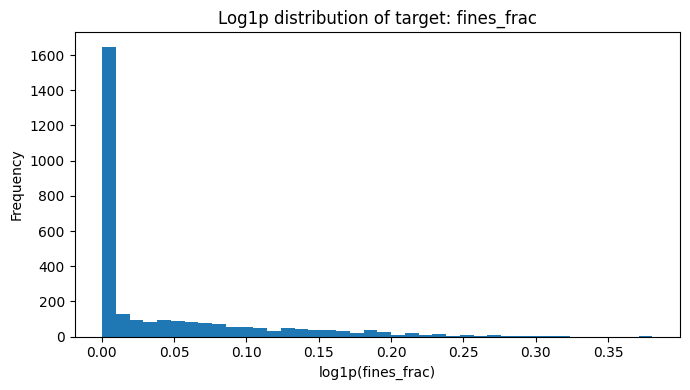

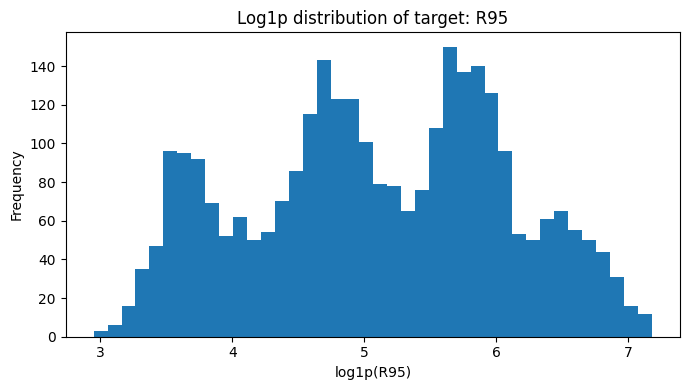

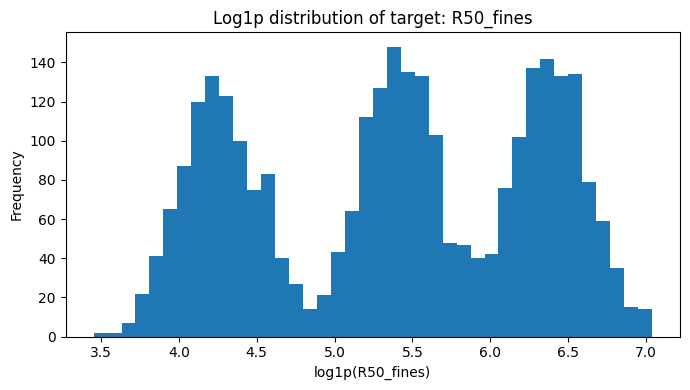

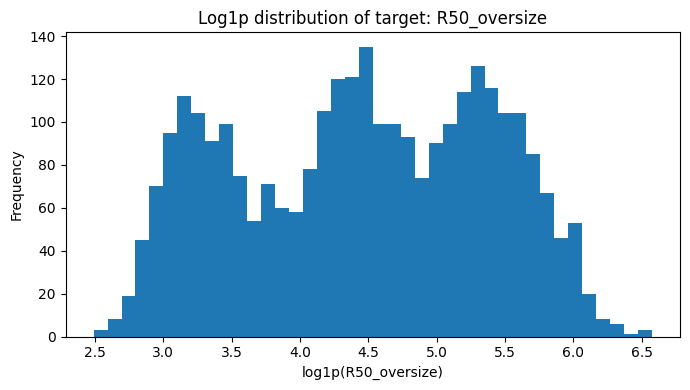

In [23]:
skewness = labels[target_cols].skew().sort_values(ascending=False)
display(skewness)

log_candidate_targets = ["fines_frac", "R95", "R50_fines", "R50_oversize"]

for col in log_candidate_targets:
    plt.figure(figsize=(7, 4))
    plt.hist(np.log1p(labels[col]), bins=40)
    plt.title(f"Log1p distribution of target: {col}")
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### Target Transformation Strategy

Transformations to test:

- `log1p(R95)`
- `log1p(R50_fines)`
- `log1p(R50_oversize)`
- `log1p(fines_frac)`

Important: if a target is transformed during training, predictions must be transformed back with `expm1()` before creating the submission file.

For `P80` and `oversize_frac`, raw-target modeling may be a good first baseline.

## 16. Modeling Strategy for the Next Notebook

Recommended baseline modeling sequence:

1. **Baseline models without feature engineering**
   - Ridge Regression
   - RandomForestRegressor
   - ExtraTreesRegressor
   - HistGradientBoostingRegressor

2. **Stronger tabular models**
   - XGBoostRegressor
   - LightGBMRegressor
   - CatBoostRegressor

3. **Target-specific modeling**
   - Train one model per target.
   - Use different transformations depending on target skewness.

4. **Validation strategy**
   - Standard KFold for initial comparison.
   - Group-style validation by gravity regime.
   - Stress-test validation on high-energy or low-gravity subsets.

5. **Feature importance and interpretability**
   - Permutation importance
   - Model feature importance
   - SHAP for the best models

6. **Submission**
   - Generate `prediction_submission.csv` with exactly:
     - `scenario_id`
     - `P80`
     - `fines_frac`
     - `oversize_frac`
     - `R95`
     - `R50_fines`
     - `R50_oversize`

## 17. Inverse Design Strategy

The inverse design task is optional but can improve the final challenge score.

Constraints:

- `96 <= P80 <= 101`
- `R95 <= 175`

Suggested strategy:

1. Train the best forward-prediction model.
2. Generate many candidate input scenarios inside the allowed bounds from `constraints.json`.
3. Predict `P80` and `R95`.
4. Keep candidates satisfying:
   - `96 <= P80 <= 101`
   - `R95 <= 175`
5. Rank valid candidates by:
   - lower energy,
   - lower R95,
   - prediction confidence or stability across model ensemble.
6. Submit the top 20 scenarios.

Search methods to test:
- random search
- Latin hypercube sampling
- Optuna optimization
- ensemble-based filtering

## 18. EDA Summary and Next Steps

### Key EDA Findings

- The dataset contains 2930 training scenarios and 492 test scenarios.
- The task is a multi-output regression problem with 8 inputs and 6 targets.
- No missing values were detected.
- Several input variables show separated simulation regimes.
- `gravity` behaves like a discrete physical environment variable.
- `P80` is bimodal.
- `fines_frac` is highly right-skewed.
- `oversize_frac` has two main regimes.
- Distance targets are strongly right-skewed and heavily controlled by gravity.
- Correlation and scatter plots support physics-inspired feature engineering.

### Next Notebook

The next notebook should be:

`02_baseline_models.ipynb`

Main objectives:
1. Build baseline regression models.
2. Evaluate each target separately.
3. Compare raw features vs engineered features.
4. Test log-transformations for skewed targets.
5. Select the first strong model for submission.

# Hypothisis test 

In [24]:
from scipy.stats import pearsonr, spearmanr

corr_tests = []

for x_col in input_cols:
    for y_col in target_cols:
        pearson_corr, pearson_p = pearsonr(df[x_col], df[y_col])
        spearman_corr, spearman_p = spearmanr(df[x_col], df[y_col])
        
        corr_tests.append({
            "input": x_col,
            "target": y_col,
            "pearson_corr": pearson_corr,
            "pearson_pvalue": pearson_p,
            "spearman_corr": spearman_corr,
            "spearman_pvalue": spearman_p
        })

corr_tests_df = pd.DataFrame(corr_tests)
display(corr_tests_df.sort_values("spearman_corr", key=abs, ascending=False))

,input,target,pearson_corr,pearson_pvalue,spearman_corr,spearman_pvalue
34,gravity,R50_fines,-0.803886,0.000000e+00,-0.941830,0.000000e+00
35,gravity,R50_oversize,-0.744055,0.000000e+00,-0.931707,0.000000e+00
33,gravity,R95,-0.676681,0.000000e+00,-0.896280,0.000000e+00
18,strength,P80,0.916946,0.000000e+00,0.872582,0.000000e+00
20,strength,oversize_frac,0.921171,0.000000e+00,0.872188,0.000000e+00
19,strength,fines_frac,-0.732616,0.000000e+00,-0.863148,0.000000e+00
25,porosity,fines_frac,0.644762,0.000000e+00,0.758130,0.000000e+00
26,porosity,oversize_frac,-0.923171,0.000000e+00,-0.757494,0.000000e+00
24,porosity,P80,-0.906075,0.000000e+00,-0.756934,0.000000e+00
8,angle_rad,oversize_frac,0.883424,0.000000e+00,0.749762,0.000000e+00


# ANOVA classique

In [25]:
from scipy.stats import f_oneway

for target in ["R95", "R50_fines", "R50_oversize"]:
    groups = [group[target].values for _, group in df.groupby("gravity")]
    stat, p = f_oneway(*groups)
    print(target, "ANOVA F-stat:", stat, "p-value:", p)

R95 ANOVA F-stat: 2300.758036419995 p-value: 0.0
R50_fines ANOVA F-stat: 8759.494066868014 p-value: 0.0
R50_oversize ANOVA F-stat: 4162.4770983692315 p-value: 0.0


# Kruskal-Wallis

In [26]:
from scipy.stats import kruskal

for target in ["R95", "R50_fines", "R50_oversize"]:
    groups = [group[target].values for _, group in df.groupby("gravity")]
    stat, p = kruskal(*groups)
    print(target, "Kruskal-Wallis H-stat:", stat, "p-value:", p)

R95 Kruskal-Wallis H-stat: 2354.4392877616247 p-value: 0.0
R50_fines Kruskal-Wallis H-stat: 2598.151710132899 p-value: 0.0
R50_oversize Kruskal-Wallis H-stat: 2542.7224187593147 p-value: 0.0
